<a href="https://colab.research.google.com/github/ayatayoub20/Prediction-of-Product-Sales/blob/main/Prediction_of_Product_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prediction of Product Sales


- Author: Ayat Ayoub

## Project Overview


## Load and Inspect Data







In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/01-Fundamentals/Week02/Data/sales_predictions_2023.csv')

# Preview data
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


## Clean Data



1) How many rows and columns?

In [ ]:
df.shape

(8523, 12)

2) What are the datatypes of each variable?

In [ ]:
df.dtypes

,0
Item_Identifier,object
Item_Weight,float64
Item_Fat_Content,object
Item_Visibility,float64
Item_Type,object
Item_MRP,float64
Outlet_Identifier,object
Outlet_Establishment_Year,int64
Outlet_Size,object
Outlet_Location_Type,object


3) Are there duplicates?

In [ ]:
float(df.duplicated().sum())

0.0

4) Identify missing values

In [ ]:
df.isna().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


5) Address missing values using placeholder value

In [ ]:
df['Outlet_Size'] = df['Outlet_Size'].fillna('Unknown')

In [ ]:
df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].mean())

6) Confirm no missing values

In [ ]:
df.isna().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


7) Fix inconsistent categories

In [ ]:
df['Item_Fat_Content'].value_counts()
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular'
})

In [ ]:
df['Item_Fat_Content'].value_counts()


,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


8) Summary statistics for numerical columns

In [ ]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.226124,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,9.310000,0.026989,93.826500,1987.000000,834.247400
50%,12.857645,0.053931,143.012800,1999.000000,1794.331000
75%,16.000000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [ ]:
df[['Item_Weight','Item_Visibility','Item_MRP','Item_Outlet_Sales']].agg(['min','max','mean'])

,Item_Weight,Item_Visibility,Item_MRP,Item_Outlet_Sales
min,4.555000,0.000000,31.290000,33.290000
max,21.350000,0.328391,266.888400,13086.964800
mean,12.857645,0.066132,140.992782,2181.288914


## Exploratory Data Analysis


**1) Histogram section**

This plot displays the distribution of product sales.

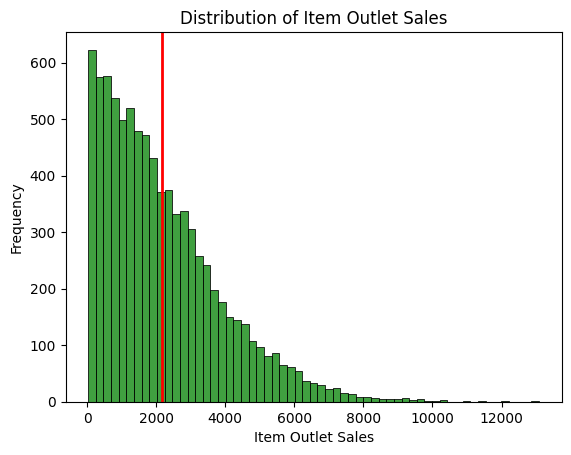

In [ ]:
#Distribution of Item Outlet Sales by histogram
mean = df['Item_Outlet_Sales'].mean()
ax = sns.histplot(data=df,x='Item_Outlet_Sales',color='green')
ax.axvline(mean,color='red',linewidth=2);
ax.set_title('Distribution of Item Outlet Sales');
ax.set_xlabel('Item Outlet Sales');
ax.set_ylabel('Frequency');

The distribution is right-skewed, with most products having low to moderate sales, and a small number of products having very high sales. The mean is higher than most values due to these high outliers.

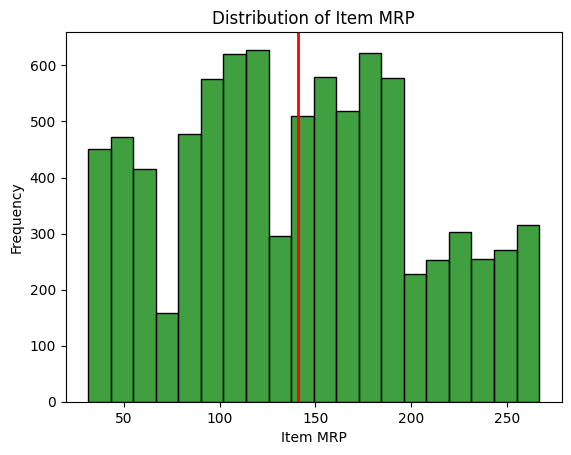

In [ ]:
mean = df['Item_MRP'].mean()
ax = sns.histplot(data=df,x='Item_MRP',color='green',bins=20)
ax.axvline(mean,color='red',linewidth=2);
ax.set_title('Distribution of Item MRP');
ax.set_xlabel('Item MRP');
ax.set_ylabel('Frequency');

Item_MRP is concentrated around the middle price range, suggesting that most products are moderately priced.

**2) Boxplot section**

/tmp/ipykernel_3271/3084735285.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=45);


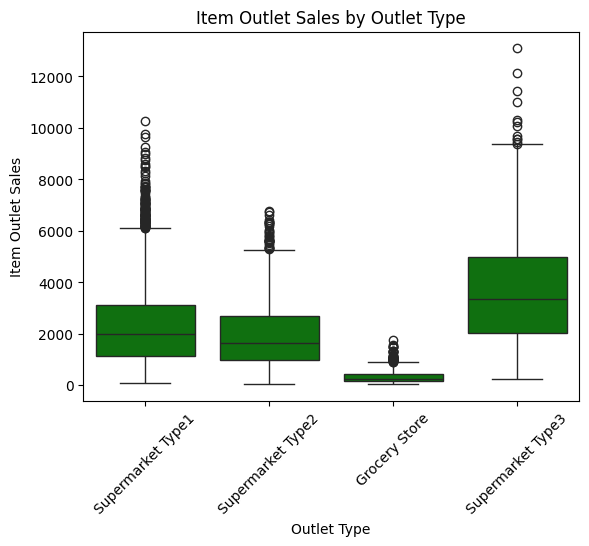

In [ ]:
ax = sns.boxplot(data=df,x='Outlet_Type',y='Item_Outlet_Sales',color='green');
ax.set_xticklabels(ax.get_xticklabels(),rotation=45);
ax.set_title('Item Outlet Sales by Outlet Type');
ax.set_xlabel('Outlet Type');
ax.set_ylabel('Item Outlet Sales');



Item outlet sales vary significantly across outlet types. Supermarket Type3 has the highest sales, while Grocery Stores have the lowest, suggesting that store type strongly influences sales performance.

/tmp/ipykernel_3271/2004735174.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=45,ha='right');


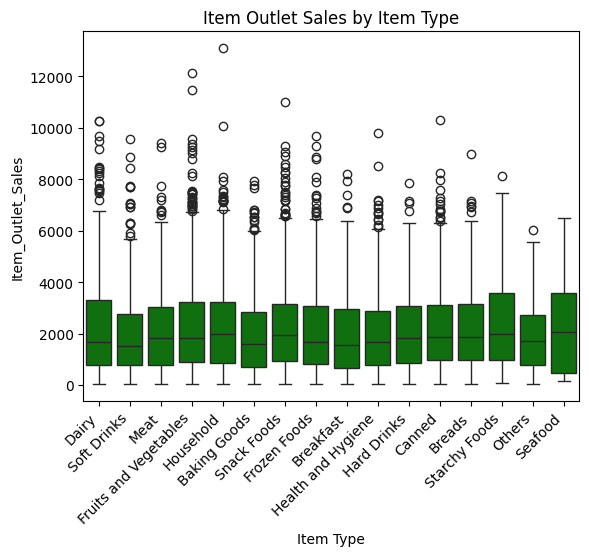

In [ ]:
ax = sns.boxplot(data=df,x='Item_Type',y='Item_Outlet_Sales',color='green');
ax.set_xticklabels(ax.get_xticklabels(),rotation=45,ha='right');
ax.set_title('Item Outlet Sales by Item Type');
ax.set_xlabel('Item Type');

Sales are relatively similar across different item types, with no major differences between categories. This suggests that product type has a smaller impact on sales compared to other factors.

**3) Countplot section**

/tmp/ipykernel_3271/2434891732.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=45);


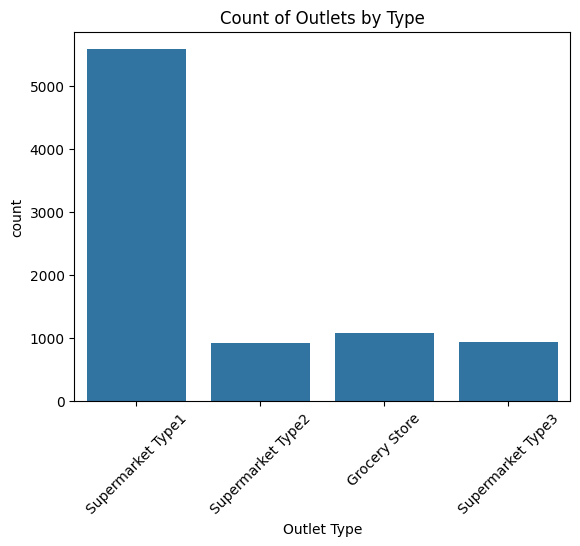

In [ ]:
ax = sns.countplot(data=df, x='Outlet_Type');
ax.set_xticklabels(ax.get_xticklabels(),rotation=45);
ax.set_title('Count of Outlets by Type');
ax.set_xlabel('Outlet Type');

Most outlets belong to Supermarket Type1, while other types appear less frequently.

**4) Heatmap**

<Axes: >

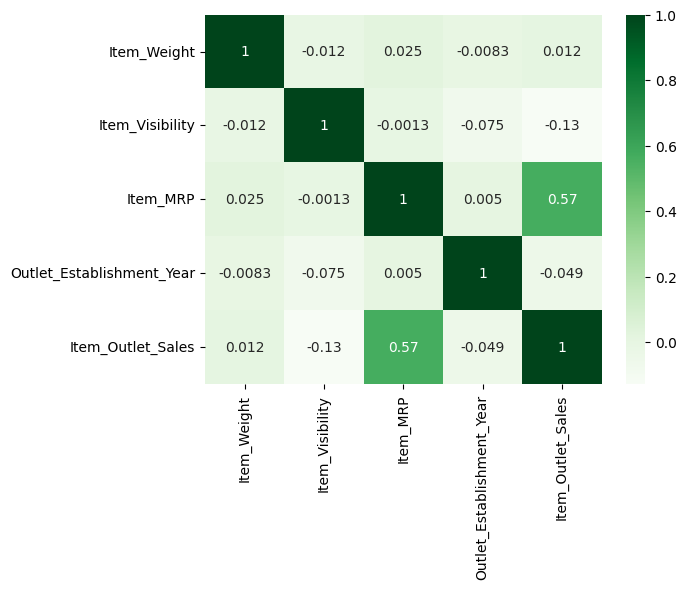

In [ ]:
corr = df.select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True, cmap='Greens')


Item_MRP has the strongest positive correlation with sales, while other variables have little to no impact.

## Future Inspection


Remove ALL placeholders and return them to NaN

In [ ]:
# categorical
df['Outlet_Size'] = df['Outlet_Size'].replace('Unknown', np.nan)

# numerical
df_original = pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/01-Fundamentals/Week02/Data/sales_predictions_2023.csv')
df['Item_Weight'] = df_original['Item_Weight']

## Item_MRP
Maximum Retail Price (list price) of the product


Univariate

Text(0.5, 1.0, 'Distribution of Item MRP')

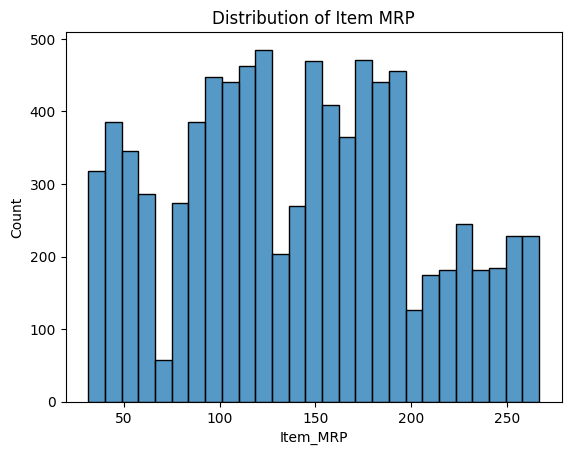

In [ ]:
sns.histplot(data=df, x='Item_MRP')
plt.title('Distribution of Item MRP')

- Item_MRP values are spread across a wide range, with most products falling in the mid-price range.
- There are fewer products at very low and very high prices.

- Type: Numeric  
- Null values: No missing values  
- Constant/quasi-constant: No  
- Cardinality: High (many unique values)  
- Known before target: Yes  
- Business reason to exclude: No, price is an important factor in sales  

Multivariate

Text(0.5, 1.0, 'Item  MRP  vs Sales')

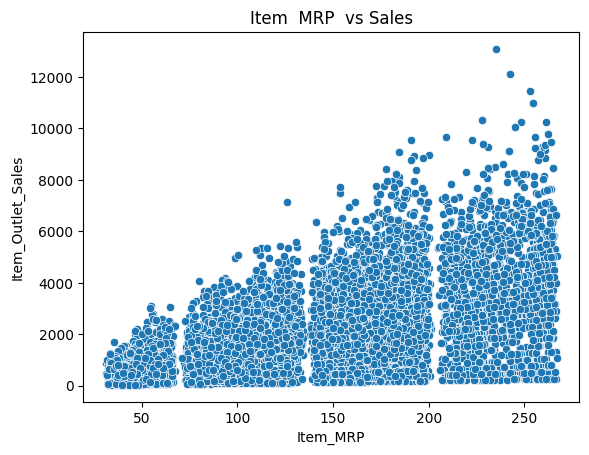

In [ ]:
sns.scatterplot(data=df, x='Item_MRP', y='Item_Outlet_Sales')
plt.title('Item  MRP  vs Sales')

This scatter plot shows the relationship between the product price (Item_MRP) and the sales (Item_Outlet_Sales).
We can observe a positive relationship, where higher-priced items tend to have higher sales.
The data is grouped into clusters, which may represent different pricing categories.
Also, there are some outliers with very high sales values.
Overall, price appears to be an important factor influencing sales.

- Expected predictor: Yes, price is likely to affect sales  
- Appears to be a predictor: Yes, there is a clear positive relationship  

## Outlet_Type
Whether the outlet is a grocery store or some sort of supermarket

Univariate

Text(0.5, 1.0, 'Count of Outlet Type')

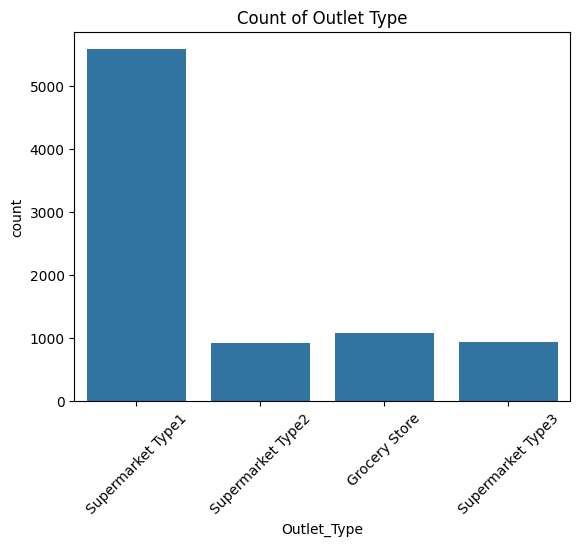

In [ ]:
sns.countplot(data=df, x='Outlet_Type')
plt.xticks(rotation=45)
plt.title('Count of Outlet Type')

Most outlets are of type Supermarket Type1, while other outlet types appear much less frequently.

- Type: Categorical (nominal)  
- Null values: No missing values  
- Constant/quasi-constant: No  
- Cardinality: Low (4 categories)  
- Known before target: Yes  
- Business reason to exclude: No  

Multivariate

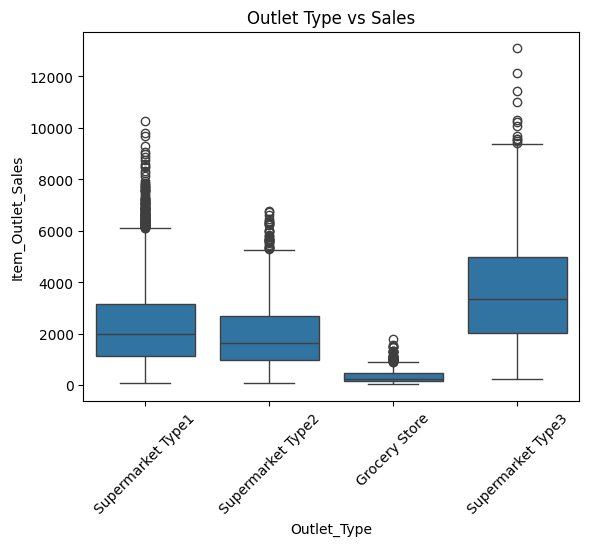

In [ ]:
sns.boxplot(data=df, x='Outlet_Type', y='Item_Outlet_Sales')
plt.xticks(rotation=45)
plt.title('Outlet Type vs Sales')
plt.show()

Supermarket Type3 shows higher sales compared to other outlet types, while Grocery Stores have the lowest sales.

- Expected predictor: Yes, outlet type likely affects sales  
- Appears to be a predictor: Yes, there are clear differences in sales between outlet types  

## Outlet_Size
The size of the store in terms of ground area covered

Univariate

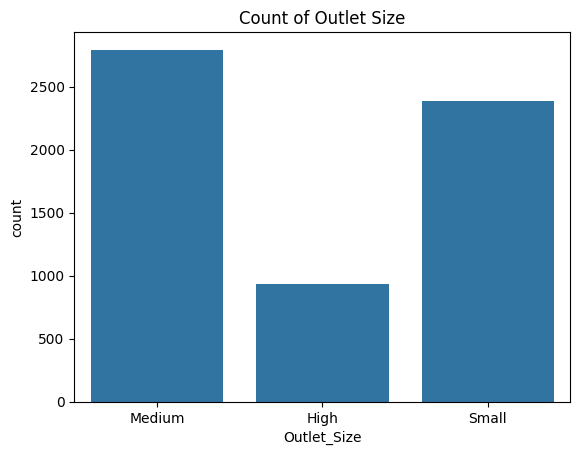

In [ ]:
sns.countplot(data=df, x='Outlet_Size');
plt.title('Count of Outlet Size');

Most outlets are medium and small in size, while large outlets are fewer in number

- Type: Categorical (nominal)  
- Null values: There are missing values  
- Suggested handling: Impute with mode or keep as missing  
- Constant/quasi-constant: No  
- Cardinality: Low (3 categories)  
- Known before target: Yes  
- Business reason to exclude: No  

Multivariate

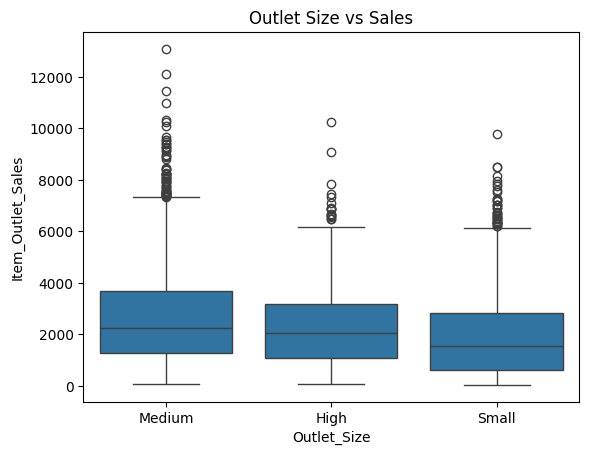

In [ ]:
sns.boxplot(data=df, x='Outlet_Size', y='Item_Outlet_Sales');
plt.title('Outlet Size vs Sales');

Medium outlets tend to have higher sales, while small outlets have lower sales

- Expected predictor: Yes, store size likely affects sales  
- Appears to be a predictor: Yes, there are noticeable differences in sales between sizes

## Item_Weight
Weight of product

Univariate

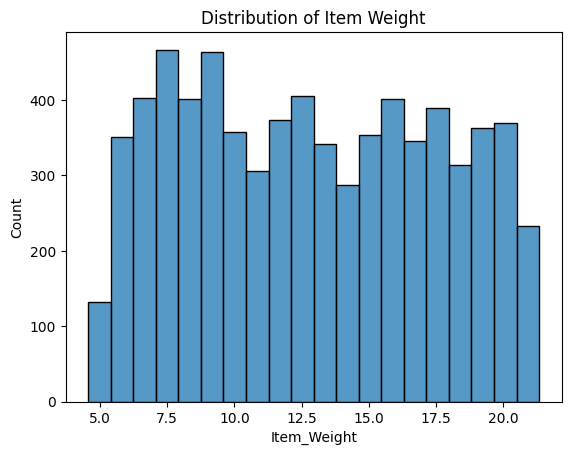

In [ ]:
sns.histplot(data=df, x='Item_Weight');
plt.title('Distribution of Item Weight');

Item weights are fairly evenly distributed across a wide range

- Type: Numeric  
- Null values: There are missing values  
- Suggested handling: Impute using mean  
- Constant/quasi-constant: No  
- Cardinality: High  
- Known before target: Yes  
- Business reason to exclude: No  

Multivariate

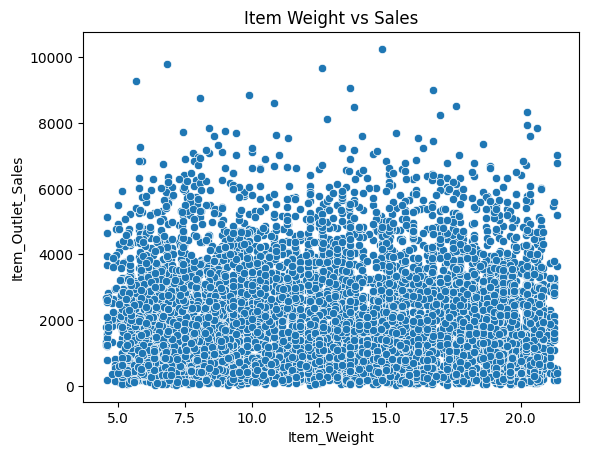

In [ ]:
sns.scatterplot(data=df, x='Item_Weight', y='Item_Outlet_Sales')
plt.title('Item Weight vs Sales')
plt.show()

There is no clear relationship between item weight and sales, as sales values are spread across all weight values.

- Expected predictor: Possibly, but not strong  
- Appears to be a predictor: No, there is no clear relationship  